<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [16]</a>'.</span>

In [1]:
from tmu.models.classification.vanilla_classifier import TMClassifier
import numpy as np
import os 
import logging
import config
import pickle
from utils.optuna import save_optuna_best_results, load_optuna_best_results, run_tm_optuna_search
from utils.dataset import load_dataset
from utils.plots import plot_tm_roc_curve, plot_confusion_matrix_from_scores, plot_clause_length_distribution
from utils.booleanization import perform_color_thermometers_booleanization
from utils.training import train_tm_and_save_scores

/home/coder/masters_thesis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-03-01 19:42:40,835 - matplotlib - DEBUG - matplotlib data path: /home/coder/masters_thesis/venv/lib/python3.12/site-packages/matplotlib/mpl-data


2026-03-01 19:42:40,845 - matplotlib - DEBUG - CONFIGDIR=/home/coder/.config/matplotlib


2026-03-01 19:42:40,859 - matplotlib - DEBUG - interactive is False


2026-03-01 19:42:40,859 - matplotlib - DEBUG - platform is linux


2026-03-01 19:42:40,945 - matplotlib - DEBUG - CACHEDIR=/home/coder/.cache/matplotlib


2026-03-01 19:42:40,948 - matplotlib.font_manager - DEBUG - Using fontManager instance from /home/coder/.cache/matplotlib/fontlist-v390.json


In [2]:
resolution=8

In [3]:
logging.getLogger("tmu").setLevel(logging.WARNING)
logging.getLogger("tmu.clause_bank.clause_bank_cuda").setLevel(logging.WARNING)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

In [4]:
X_train_org, Y_train, X_val_org, Y_val, X_test_org, Y_test = load_dataset(config)

In [5]:
X_train, X_val, X_test, Y_train, Y_val, Y_test = perform_color_thermometers_booleanization(X_train_org, X_val_org, X_test_org, Y_train, Y_val, Y_test, resolution)

In [6]:
X_train = X_train.astype(np.uint32)
X_val   = X_val.astype(np.uint32)
X_test  = X_test.astype(np.uint32)
Y_test  = Y_test.astype(np.uint32)
Y_train  = Y_train.astype(np.uint32)

In [7]:
study = run_tm_optuna_search(TMClassifier, config, X_train, Y_train, X_val, Y_val, metric="accuracy", pos_label=None)

[I 2026-03-01 19:42:41,546] A new study created in memory with name: no-name-6d1753f4-b3d8-47dd-8c5f-93116c2b2477


[I 2026-03-01 19:51:38,600] Trial 0 finished with value: 0.8205128205128205 and parameters: {'s': 6.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 0 with value: 0.8205128205128205.


[I 2026-03-01 20:00:23,691] Trial 1 finished with value: 0.8717948717948718 and parameters: {'s': 1.0, 'T': 10000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 1 with value: 0.8717948717948718.


[I 2026-03-01 20:11:01,298] Trial 2 finished with value: 0.9102564102564102 and parameters: {'s': 10.0, 'T': 2000, 'patch_size': 9, 'max_included_literals': 128}. Best is trial 2 with value: 0.9102564102564102.


[I 2026-03-01 20:20:46,174] Trial 3 finished with value: 0.8717948717948718 and parameters: {'s': 10.0, 'T': 2500, 'patch_size': 7, 'max_included_literals': 128}. Best is trial 2 with value: 0.9102564102564102.


...

[I 2026-03-02 04:15:47,649] Trial 46 finished with value: 0.8333333333333334 and parameters: {'s': 11.0, 'T': 7000, 'patch_size': 3, 'max_included_literals': 64}. Best is trial 12 with value: 0.9487179487179487.


[I 2026-03-02 04:26:53,157] Trial 47 finished with value: 0.9102564102564102 and parameters: {'s': 14.0, 'T': 4500, 'patch_size': 7, 'max_included_literals': 32}. Best is trial 12 with value: 0.9487179487179487.


[I 2026-03-02 04:37:14,587] Trial 48 finished with value: 0.8846153846153846 and parameters: {'s': 2.0, 'T': 10000, 'patch_size': 7, 'max_included_literals': 512}. Best is trial 12 with value: 0.9487179487179487.


[I 2026-03-02 04:47:17,491] Trial 49 finished with value: 0.9102564102564102 and parameters: {'s': 1.0, 'T': 6000, 'patch_size': 5, 'max_included_literals': 32}. Best is trial 12 with value: 0.9487179487179487.


Best accuracy: 0.9487179487179487
Best hyperparameters: {'s': 4.0, 'T': 4500, 'patch_size': 7, 'max_included_literals': 32}


In [8]:
best_params = study.best_params
print("Best F1 score macro accuracy:", study.best_value)
print("Best hyperparameters:", best_params)
save_optuna_best_results(study, "hyperparameters/color_thermometers_accuracy.json")

Best F1 score macro accuracy: 0.9487179487179487
Best hyperparameters: {'s': 4.0, 'T': 4500, 'patch_size': 7, 'max_included_literals': 32}
Best Optuna results saved to hyperparameters/color_thermometers_accuracy.json


In [9]:
best_value, best_params = load_optuna_best_results("hyperparameters/color_thermometers_accuracy.json")
s_best = best_params["s"]
T_best = best_params["T"]
patch_best = best_params["patch_size"]
weighted_best = 1
maxlit_best = best_params["max_included_literals"]

In [10]:
tm = train_tm_and_save_scores(
    TMClassifier=TMClassifier,
    config=config,
    X_train=X_train,
    Y_train=Y_train,
    X_test=X_test,
    Y_test=Y_test,
    T=T_best,
    s=s_best,
    patch_dim=patch_best,
    max_included_literals=maxlit_best,
    weighted_clauses=weighted_best,
    specialist_name="BreastMNIST_Color_Thermometers_Accuracy",
    save_dir=config.SAVE_DIR_SCORES,
)


Accuracy over 100 epochs:



#1 Accuracy: 77.56% (38.27s)


#2 Accuracy: 80.13% (36.71s)


#3 Accuracy: 60.90% (35.10s)


#4 Accuracy: 83.33% (33.99s)


...

#96 Accuracy: 88.46% (19.44s)


#97 Accuracy: 88.46% (19.44s)


#98 Accuracy: 88.46% (19.39s)


#99 Accuracy: 88.46% (19.54s)


#100 Accuracy: 89.10% (19.45s)


In [11]:
os.makedirs("saved_models", exist_ok=True)
model_path = os.path.join("saved_models", "BreastMNIST_Color_Thermometers_Specialist_Accuracy.pkl")

In [12]:
if not os.path.exists(model_path):
    with open(model_path, "wb") as f:
        pickle.dump(tm, f)
    print("Model saved.")
else:
    print("Model already exists. Skipping save.")

Model saved.


In [13]:
with open(model_path, "rb") as f:
    tm = pickle.load(f)

2026-03-02 05:26:06,307 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


2026-03-02 05:26:06,310 - matplotlib.pyplot - DEBUG - Loaded backend module://matplotlib_inline.backend_inline version unknown.


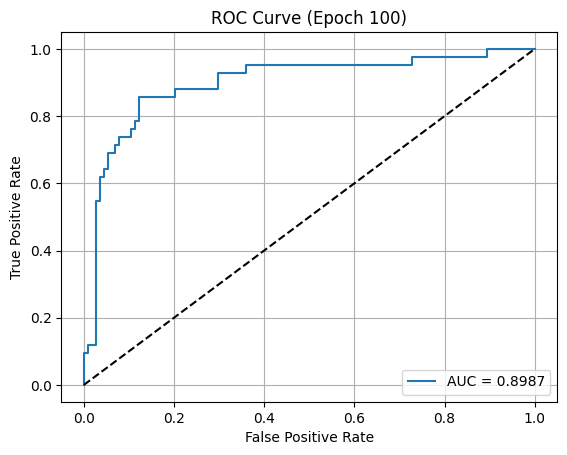

0.8987050960735171

In [14]:
plot_tm_roc_curve(config, T_best, s_best, patch_best, maxlit_best, weighted_best, 
                Y_test, "BreastMNIST_Color_Thermometers_Accuracy")

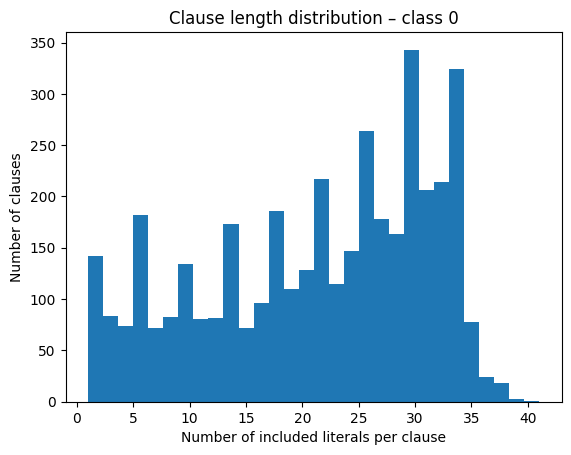

Class 0: median=23.0, mean=21.2, std=9.9


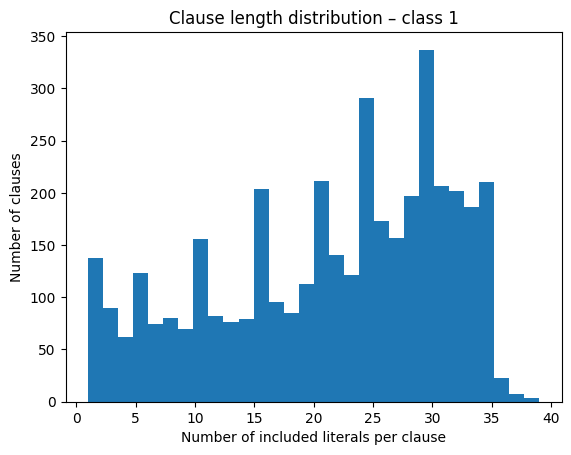

Class 1: median=23.0, mean=21.4, std=9.7


In [15]:
_ = plot_clause_length_distribution(tm)

<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [16]:
_, _ =  plot_confusion_matrix_from_scores(config,  T_best, s_best, patch_best, maxlit_best, weighted_best, 
                                   Y_test, "BreastMNIST_Color_Thermometer_Accuracy")

FileNotFoundError: BreastMNIST/results_BreastMNIST_scores/BreastMNIST_Color_Thermometer_Accuracy_100_2000_4500_4.0_7_32_1.txt not found.